# Gradient descent, an example

In this notebook, we will implement gradient descent from scratch on a simple linear dataset.

In [12]:
# Dependencies
import numpy as np
import matplotlib.pyplot as plt

## 1. Generate a linear dataset

First, we will generate a dataset with a known slope and intercept, plus some noise.

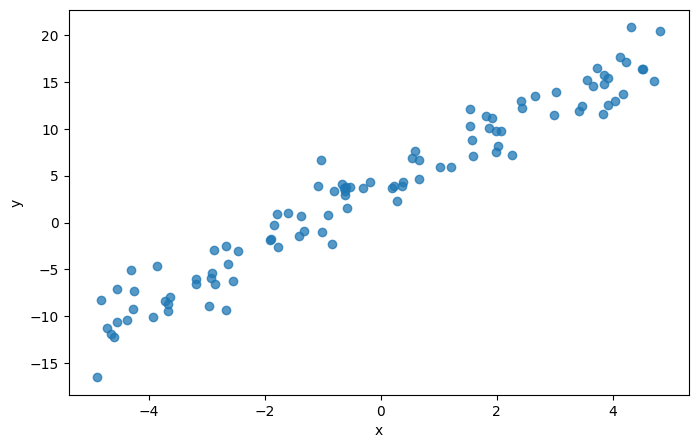

In [13]:
np.random.seed(1000)

# True parameters
true_theta_0 = 4.0   # intercept
true_theta_1 = 3.0   # slope

# Generate 100 data points
m_total = 100
x_all = np.random.uniform(-5, 5, m_total)
# Here, we create and apply a noise model
noise = np.random.normal(0, 2, m_total)
y_all = true_theta_0 + true_theta_1 * x_all + noise

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_all, y_all, alpha=0.75)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

## 2. Cost function and partial derivatives

Recall:

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)$$

$$\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x^{(i)}$$

In [ ]:
def compute_cost(theta_0, theta_1, x, y):
    """Compute the mean squared error cost function."""
    m = len(x)
    predictions = theta_0 + theta_1 * x
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


def compute_gradients(theta_0, theta_1, x, y):
    """Compute the partial derivatives of J with respect to theta_0 and theta_1."""
    m = len(x)
    predictions = theta_0 + theta_1 * x
    errors = predictions - y
    dJ_dtheta0 = (1 / m) * np.sum(errors)
    dJ_dtheta1 = (1 / m) * np.sum(errors * x)
    return dJ_dtheta0, dJ_dtheta1

## 3. Contour plot of the cost function

Let's visualize $J(\theta_0, \theta_1)$ over a grid of parameter values using the full dataset. The minimum should be near the true values ($\theta_0 = 4$, $\theta_1 = 3$).

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


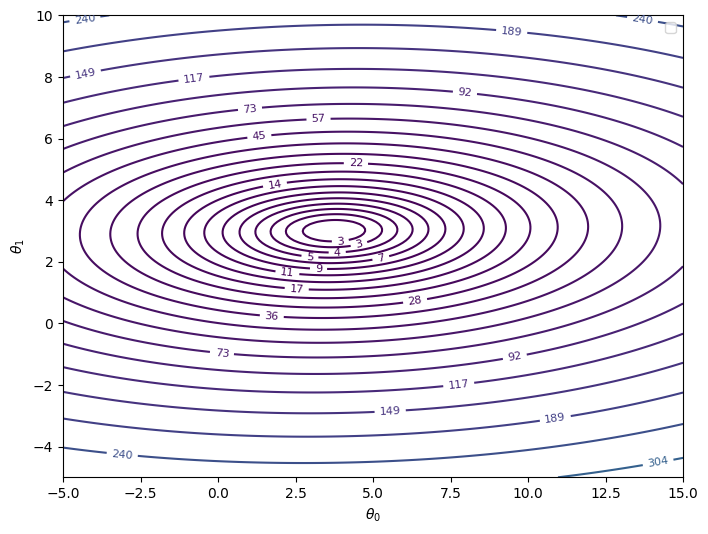

In [14]:
# Create a grid of theta_0 and theta_1 values
theta_0_vals = np.linspace(-5, 15, 200)
theta_1_vals = np.linspace(-5, 10, 200)
T0, T1 = np.meshgrid(theta_0_vals, theta_1_vals)

# Compute cost at each grid point
J_vals = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = compute_cost(T0[i, j], T1[i, j], x_all, y_all)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contour(T0, T1, J_vals, levels=np.logspace(0, 3, 30), cmap='viridis')
ax.clabel(contour, inline=True, fontsize=8, fmt='%.0f')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.legend()
plt.show()

## 4. Split data into training and test sets

In [ ]:
# Split your data

## 5. Implement gradient descent

Your task: fill in the body of the `while` loop to perform batch gradient descent.

At each iteration you need to:
1. Compute the gradients using the training data.
2. Update $\theta_0$ and $\theta_1$ **simultaneously**.
3. Compute and store the cost.
4. Check for convergence.

In [ ]:
# Hyperparameters
alpha = 0.01         # learning rate
tolerance = 1e-6     # Our convergence boundaries
max_iterations = 10000

# Initialize parameters
theta_0 = 0.0
theta_1 = 0.0

# Track the cost and parameter history
cost_history = []
theta_history = [(theta_0, theta_1)]

iteration = 0
converged = False

while not converged and iteration < max_iterations:
    # ---- YOUR CODE HERE ----

    # 1. Compute the partial derivatives dJ/dtheta_0 and dJ/dtheta_1
    #    using compute_gradients() on the training data
    # grad_0, grad_1 = ...

    # 2. Update theta_0 and theta_1 simultaneously
    # theta_0 = ...
    # theta_1 = ...

    # 3. Compute the current cost and append to cost_history
    # cost = ...
    # cost_history.append(cost)

    # 4. Store the current parameters
    # theta_history.append((theta_0, theta_1))

    # 5. Check for convergence: if the cost changed by less than
    #    tolerance since the last iteration, set converged = True
    # if len(cost_history) > 1 and ...:
    #     converged = True

    # ---- END YOUR CODE ----

    iteration += 1

print(f'Converged after {iteration} iterations')
print(f'theta_0 = {theta_0:.4f} (true: {true_theta_0})')
print(f'theta_1 = {theta_1:.4f} (true: {true_theta_1})')
print(f'Final cost: {cost_history[-1]:.4f}')

## 6. Visualize the results

Run these cells once your gradient descent is working.

In [ ]:
# Plot cost vs. iteration
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_history)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$J(\theta_0, \theta_1)$')
plt.show()

In [ ]:
# Plot the gradient descent path on the contour plot
theta_history = np.array(theta_history)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(T0, T1, J_vals, levels=np.logspace(0, 3, 30), cmap='viridis', alpha=0.5)
ax.plot(theta_history[:, 0], theta_history[:, 1], 'r.-', markersize=3, linewidth=0.5, label='GD path')
ax.plot(theta_history[0, 0], theta_history[0, 1], 'go', markersize=10, label='Start')
ax.plot(theta_history[-1, 0], theta_history[-1, 1], 'r*', markersize=15, label='End')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.legend()
plt.show()

In [ ]:
# Plot the fitted line against the data
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_train, y_train, alpha=0.5, label='Training data')
ax.scatter(x_test, y_test, alpha=0.5, marker='s', label='Test data')

x_line = np.linspace(x_all.min(), x_all.max(), 100)
y_line = theta_0 + theta_1 * x_line
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Fit: y = {theta_0:.2f} + {theta_1:.2f}x')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

# Report test cost
test_cost = compute_cost(theta_0, theta_1, x_test, y_test)
print(f'Cost on test set: {test_cost:.4f}')